# Avaliaçao de diferentes modelos e Feature engengineering

**Dataset**: Telco_customer_churn_preprocessed.csv

**Objetivo**: Realizar o tuning de hyperparametros para diferentes modelos de classificação e seleção do melhor modelo para baseline.

## 1. Setup e Imports
Consolidação de todas as bibliotecas necessárias para a análise.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, RepeatedStratifiedKFold, HalvingRandomSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from scipy.stats import randint, uniform
import mlflow
import mlflow.sklearn
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

## 2. Importando dataset pré-processado
Carregamento do dataset pré-processado anteriormente no processo de EDA.

In [44]:
# Carregar dataset pré-processado
path = "../data/raw/Telco_customer_churn_preprocessed.csv"

df = pd.read_csv(path)
target = 'target'

# Garantir coluna alvo presente e binária
assert target in df.columns, f"Coluna '{target}' não encontrada no dataset pré-processado."

# Remover colunas de metadados caso existam
for col in ['id', 'dataset', 'zip_code']:  # Removido: data leakage e overfitting geográfico
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

print(f"Dataset shape (pré-processado): {df.shape}")
print(f"\nTarget => (0 = Sem churn, 1 = Com churn):")
print(df[target].value_counts())

df.head()

Dataset shape (pré-processado): (7043, 30)

Target => (0 = Sem churn, 1 = Com churn):
target
0    5174
1    1869
Name: count, dtype: int64


,monthly_charges,target,average_monthly_spend,gender_Male,senior_citizen_Yes,partner_Yes,dependents_Yes,phone_service_Yes,multiple_lines_No phone service,multiple_lines_Yes,...,streaming_tv_No internet service,streaming_tv_Yes,streaming_movies_No internet service,streaming_movies_Yes,contract_One year,contract_Two year,paperless_billing_Yes,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,53.85,1,54.075000,True,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
1,70.70,1,75.825000,False,False,False,True,True,False,False,...,False,False,False,False,False,False,True,False,True,False
2,99.65,1,102.562500,False,False,False,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
3,104.80,1,108.787500,False,False,True,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,103.70,1,102.781633,True,False,False,True,True,False,True,...,False,True,False,True,False,False,True,False,False,False


## 3. Preparando os dados
- Separando os dados de teste e treino (80/20)
- Selecionando as features mais relevantes

In [45]:
# Dividindo dados em treino e teste
RANDOM_STATE = 42
FEATURES_TO_SELECT = 25  # Será validado abaixo
TEST_SIZE = 0.2

y = df[target]
X = df.drop(columns=[target])
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# ============================================================================
# ANÁLISE DE K ÓTIMO
# ============================================================================
# Testar diferentes valores de k para encontrar o balanceamento ideal
# entre redução de dimensionalidade e retenção de variância

from sklearn.feature_selection import SelectKBest, f_classif

# Testar valores de k
k_values = [15, 20, 25, 30]
k_results = []

print(f"\nAnalisando k ótimo para seleção de features (15, 20, 25, 30)...")
for k_test in k_values:
    selector = SelectKBest(f_classif, k=min(k_test, X_train.shape[1]))
    X_train_temp = selector.fit_transform(X_train, y_train)
    
    # Score médio das features selecionadas
    scores = selector.scores_
    sorted_scores = sorted(scores, reverse=True)
    avg_score_selected = np.mean(sorted_scores[:k_test]) if k_test <= len(sorted_scores) else np.mean(sorted_scores)
    avg_score_all = np.mean(scores)
    
    k_results.append({
        'k': k_test,
        'features': X_train_temp.shape[1],
        'avg_score_top_k': avg_score_selected,
        'avg_score_all': avg_score_all,
        'ratio': X_train_temp.shape[1] / X_train.shape[1]
    })
    print(f"  k={k_test}: {X_train_temp.shape[1]} features, score médio={avg_score_selected:.3f}, ratio={X_train_temp.shape[1] / X_train.shape[1]:.1%}")

# Usar FEATURES_TO_SELECT (validado manualmente, k=25 é bom balanceamento)
print(f"\nSelecionado: k={FEATURES_TO_SELECT} features")

# Criar seletor que será usado no pipeline (NÃO aplicar agora, será feito dentro do pipeline)
# Apenas para preview das features selecionadas
selector_preview = SelectKBest(f_classif, k=min(FEATURES_TO_SELECT, X_train.shape[1]))
X_train_temp = selector_preview.fit_transform(X_train, y_train)
selected_mask = selector_preview.get_support()
selected_features = [name for name, keep in zip(feature_names, selected_mask) if keep]

print(f"\nFeatures selecionadas ({len(selected_features)}):") 
for i, feat in enumerate(selected_features, 1):
    print(f"{i}. {feat}")

# Guardar para uso posterior em modelos (apenas para referência)
X_train_selected = X_train.iloc[:, selected_mask]
X_test_selected = X_test.iloc[:, selected_mask]



Analisando k ótimo para seleção de features (15, 20, 25, 30)...
  k=15: 15 features, score médio=347.812, ratio=51.7%
  k=20: 20 features, score médio=295.321, ratio=69.0%
  k=25: 25 features, score médio=242.575, ratio=86.2%
  k=30: 29 features, score médio=209.615, ratio=100.0%

Selecionado: k=25 features

Features selecionadas (25):
1. monthly_charges
2. average_monthly_spend
3. senior_citizen_Yes
4. partner_Yes
5. dependents_Yes
6. internet_service_Fiber optic
7. internet_service_No
8. online_security_No internet service
9. online_security_Yes
10. online_backup_No internet service
11. online_backup_Yes
12. device_protection_No internet service
13. device_protection_Yes
14. tech_support_No internet service
15. tech_support_Yes
16. streaming_tv_No internet service
17. streaming_tv_Yes
18. streaming_movies_No internet service
19. streaming_movies_Yes
20. contract_One year
21. contract_Two year
22. paperless_billing_Yes
23. payment_method_Credit card (automatic)
24. payment_method_Ele

## 4. Treinando diferentes algoritmos

### Passo a passo para o treinamento
1. Define um dicionário com os modelos selecionados comparar.
2. Monta um Pipeline simples incluindo um StandardScaler apenas quando o algoritmo é sensível à escala (como o SVM).
3. Treina cada modelo com os dados de treino e avaliando no conjunto de teste.
4. Consolida as métricas em uma tabela para facilitar a comparação inicial.

In [46]:

model_configs = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Support Vector Machine": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

trained_models = {}
results = []

for model_name, estimator in model_configs.items():
    steps = []
    if model_name == "Support Vector Machine":
        steps.append(("scaler", StandardScaler()))

    steps.append(("model", estimator))

    pipeline = Pipeline(steps)
    pipeline.fit(X_train, y_train)  # Nota: SelectKBest no pipeline seleciona features
    
    y_pred_train = pipeline.predict(X_train)
    y_prob_train = np.nan
    y_score_train = np.nan

    y_pred_test = pipeline.predict(X_test)
    y_prob_test = np.nan
    y_score_test = np.nan

    accuracy_train = accuracy_score(y_train, y_pred_train)
    precision_train = precision_score(y_train, y_pred_train)
    recall_train = recall_score(y_train, y_pred_train)
    f1_score_train = f1_score(y_train, y_pred_train)
    roc_auc_train = np.nan

    accuracy_test = accuracy_score(y_test, y_pred_test)
    precision_test = precision_score(y_test, y_pred_test)
    recall_test = recall_score(y_test, y_pred_test)
    f1_score_test = f1_score(y_test, y_pred_test)
    roc_auc_test = np.nan

    if hasattr(pipeline, "predict_proba"):
        y_prob_test = pipeline.predict_proba(X_test)[:, 1]
        y_prob_train = pipeline.predict_proba(X_train)[:, 1]
        roc_auc_train = roc_auc_score(y_train, y_prob_train)
        roc_auc_test = roc_auc_score(y_test, y_prob_test)
    elif hasattr(pipeline, "decision_function"):
        y_score_test = pipeline.decision_function(X_test)
        y_score_train = pipeline.decision_function(X_train)
        roc_auc_train = roc_auc_score(y_train, y_score_train)
        roc_auc_test = roc_auc_score(y_test, y_score_test)

    metrics = { 
        "accuracy_train": accuracy_train,
        "accuracy_test": accuracy_test,
        "precision_train": precision_train,
        "precision_test": precision_test,
        "recall_train": recall_train,
        "recall_test": recall_test,
        "f1_train": f1_score_train,
        "f1_test": f1_score_test,
        "roc_auc_train": roc_auc_train,
        "roc_auc_test": roc_auc_test,
    }

    print(f"=== {model_name} ===")
    print(f"Acurácia no conjunto de teste: {accuracy_test:.3f}")
    print(classification_report(y_test, y_pred_test, target_names=["Sem churn", "Com churn"]))
    print("-" * 70)

    trained_models[model_name] = pipeline

    results.append({
        "Modelo": model_name,
        **metrics,
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="roc_auc_test", ascending=False).reset_index(drop=True).round(3)

=== Logistic Regression ===
Acurácia no conjunto de teste: 0.737
              precision    recall  f1-score   support

   Sem churn       0.90      0.73      0.80      1035
   Com churn       0.50      0.76      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.79      0.74      0.75      1409

----------------------------------------------------------------------
=== Decision Tree ===
Acurácia no conjunto de teste: 0.722
              precision    recall  f1-score   support

   Sem churn       0.81      0.81      0.81      1035
   Com churn       0.48      0.47      0.47       374

    accuracy                           0.72      1409
   macro avg       0.64      0.64      0.64      1409
weighted avg       0.72      0.72      0.72      1409

----------------------------------------------------------------------
=== Random Forest ===
Acurácia no conjunto de teste: 0.770
              precisi

,Modelo,accuracy_train,accuracy_test,precision_train,precision_test,recall_train,recall_test,f1_train,f1_test,roc_auc_train,roc_auc_test
0,Gradient Boosting,0.816,0.779,0.676,0.600,0.586,0.505,0.628,0.549,0.874,0.829
1,Logistic Regression,0.750,0.737,0.518,0.503,0.806,0.765,0.631,0.607,0.849,0.827
2,Random Forest,0.998,0.770,0.998,0.582,0.995,0.476,0.996,0.524,1.000,0.802
3,Support Vector Machine,0.819,0.779,0.686,0.595,0.589,0.521,0.634,0.556,0.865,0.788
4,Decision Tree,0.998,0.722,0.999,0.476,0.993,0.473,0.996,0.475,1.000,0.642


## 5. Seleção do melhor modelo e Tuning de hiperparametros
**Objetivo**: Melhorar a performance do melhor modelo identificado na comparação anterior.

- **Alvo**: acurácia de teste > 0.86 (melhor que o modelo RandomForest sem otimização).
- **Orçamento**: Busca aleatória por 60 minutos apenas nos hiperparâmetros-chave do Random Forest.
- **Em cada amostra**: estimamos acurácia via CV estratificado (5-fold) e medimos acurácia no teste; mantemos o melhor por acurácia de teste.
- **Ao final**: reportamos se o alvo (>0.86) foi atingido e registramos melhor configuração e métricas no MLflow.

## 5.0 Tuning de Logistic Regression (Alternativa)
Testar Logistic Regression como alternativa ao Gradient Boosting
para maximizar Recall com Precision >= 55%

In [47]:
import time
from sklearn.model_selection import ParameterSampler, StratifiedKFold, cross_val_score
from scipy.stats import uniform, randint, loguniform

print("\n" + "="*70)
print("TUNING: Logistic Regression (alternativa ao Gradient Boosting)")
print("="*70)

# Parâmetros de busca para Logistic Regression
param_distributions_lr = {
    "model__C": loguniform(1e-4, 100),
    "model__solver": ["lbfgs", "saga"],
    "model__class_weight": ["balanced"],
    "model__max_iter": [1000],
}

sampler_lr = ParameterSampler(
    param_distributions=param_distributions_lr,
    n_iter=100,  # Menos que GB, mais rápido
    random_state=RANDOM_STATE
)

# Pipeline base para LR
base_pipeline_lr = Pipeline([
    ("selector", SelectKBest(f_classif, k=FEATURES_TO_SELECT)),
    ("model", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight="balanced")),
])

best_lr = {
    "params": None,
    "cv_f1": -np.inf,
    "pipeline": None,
}

n_evaluated_lr = 0
start_time_lr = time.time()
deadline_lr = start_time_lr + 120  # 2 minutos para LR (mais rápido que GB)

print(f"Iniciando tuning por até 2 min...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for i, params in enumerate(sampler_lr, start=1):
    now = time.time()
    
    if now >= deadline_lr:
        print("Tempo limite atingido; encerrando busca LR.")
        break
    
    pipeline_lr = Pipeline([
        ("selector", SelectKBest(f_classif, k=FEATURES_TO_SELECT)),
        ("model", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight="balanced")),
    ])
    
    pipeline_lr.set_params(**params)
    
    cv_scores = cross_val_score(
        pipeline_lr,
        X_train,
        y_train,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )
    
    mean_cv = float(np.mean(cv_scores))
    
    if mean_cv > best_lr["cv_f1"]:
        pipeline_lr.fit(X_train, y_train)
        
        best_lr.update({
            "params": params,
            "cv_f1": mean_cv,
            "pipeline": pipeline_lr,
        })
        
        elapsed = now - start_time_lr
        print(f"[{i}] Novo melhor LR | f1_cv={mean_cv:.4f} | t={elapsed/60:.1f}m | C={params.get('model__C', 'N/A'):.4f}")
    
    if i % 20 == 0:
        elapsed = now - start_time_lr
        remaining = max(0.0, deadline_lr - now)
        print(f"Iterações LR: {i} | melhor_f1_cv={best_lr['cv_f1']:.4f} | decorrido={elapsed/60:.1f}m | restante≈{remaining/60:.1f}m")
    
    n_evaluated_lr = i

print(f"Tuning LR concluído: {n_evaluated_lr} iterações em {(time.time() - start_time_lr)/60:.1f}m")
print(f"Melhor F1 CV (LR): {best_lr['cv_f1']:.4f}")

best_model_lr = best_lr["pipeline"] if best_lr["pipeline"] is not None else base_pipeline_lr.fit(X_train, y_train)



TUNING: Logistic Regression (alternativa ao Gradient Boosting)
Iniciando tuning por até 2 min...
[1] Novo melhor LR | f1_cv=0.6280 | t=0.0m | C=0.0177
[4] Novo melhor LR | f1_cv=0.6296 | t=0.0m | C=0.0473
Iterações LR: 20 | melhor_f1_cv=0.6296 | decorrido=0.2m | restante≈1.8m
[22] Novo melhor LR | f1_cv=0.6298 | t=0.2m | C=0.0505
[27] Novo melhor LR | f1_cv=0.6299 | t=0.2m | C=0.0437
Iterações LR: 40 | melhor_f1_cv=0.6299 | decorrido=0.3m | restante≈1.7m
Iterações LR: 60 | melhor_f1_cv=0.6299 | decorrido=0.3m | restante≈1.7m
Iterações LR: 80 | melhor_f1_cv=0.6299 | decorrido=0.4m | restante≈1.6m
Iterações LR: 100 | melhor_f1_cv=0.6299 | decorrido=0.5m | restante≈1.5m
Tuning LR concluído: 100 iterações em 0.5m
Melhor F1 CV (LR): 0.6299


In [63]:
import time
import numpy as np
import pandas as pd
from scipy.stats import randint, uniform, loguniform
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import ParameterSampler, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
)

print("\n" + "="*70)
print("TUNING: Gradient Boosting (modelo principal)")
print("="*70)

# Configurações
TIME_LIMIT_MINUTES = 3
F1_TARGET = 0.60

THRESHOLD_MIN = 0.10
THRESHOLD_MAX = 0.90
THRESHOLD_STEP = 0.01
THRESHOLD_OPTIMIZATION_METRIC = "F1"
MIN_PRECISION_CONSTRAINT = 0.50

start_time = time.time()
deadline = start_time + TIME_LIMIT_MINUTES * 60

# Pipeline base
base_pipeline = Pipeline([
    ("selector", SelectKBest(f_classif, k=FEATURES_TO_SELECT)),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
])

# Espaço de busca
param_distributions = {
    "model__n_estimators": randint(50, 301),
    "model__learning_rate": loguniform(0.01, 0.3),
    "model__max_depth": randint(1, 6),
    "model__min_samples_split": randint(2, 200),
    "model__min_samples_leaf": randint(1, 100),
    "model__subsample": uniform(0.6, 0.4),
    "model__max_features": [None, "sqrt", "log2"],
}

sampler = ParameterSampler(
    param_distributions=param_distributions,
    n_iter=1_000_000,
    random_state=RANDOM_STATE
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

best = {
    "params": None,
    "cv_f1": -np.inf,
    "pipeline": None,
}

n_evaluated = 0

print(f"Iniciando tuning por até {TIME_LIMIT_MINUTES} min. Alvo: F1 CV > {F1_TARGET}.")

# Tuning dos hiperparâmetros
for i, params in enumerate(sampler, start=1):
    now = time.time()
    
    if now >= deadline:
        print("Tempo limite atingido; encerrando busca.")
        break
    
    pipeline = Pipeline([
        ("selector", SelectKBest(f_classif, k=FEATURES_TO_SELECT)),
        ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ])
    
    pipeline.set_params(**params)
    
    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )
    
    mean_cv = float(np.mean(cv_scores))
    
    if mean_cv > best["cv_f1"]:
        pipeline.fit(X_train, y_train)
        
        best.update({
            "params": params,
            "cv_f1": mean_cv,
            "pipeline": pipeline,
        })
        
        elapsed = now - start_time
        
        print(f"[{i}] Novo melhor | f1_cv={mean_cv:.4f} | t={elapsed/60:.1f}m | params={params}")
    
    if i % 10 == 0:
        elapsed = now - start_time
        remaining = max(0.0, deadline - now)
        
        print(f"Iterações: {i} | melhor_f1_cv={best['cv_f1']:.4f} | decorrido={elapsed/60:.1f}m | restante≈{remaining/60:.1f}m")
    
    n_evaluated = i

# Recupera melhor modelo
best_model = best["pipeline"]

if best_model is None:
    best_model = base_pipeline.fit(X_train, y_train)

# Tuning do threshold
y_proba = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(THRESHOLD_MIN, THRESHOLD_MAX + THRESHOLD_STEP, THRESHOLD_STEP)

threshold_results = []

for threshold in thresholds:
    y_pred = (y_proba >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, y_proba),
    })

threshold_results_df = pd.DataFrame(threshold_results)

# CORREÇÃO: Respeitar constraint Precision >= MIN_PRECISION_CONSTRAINT ANTES de otimizar
filtered_df = threshold_results_df[threshold_results_df["Precisão"] >= MIN_PRECISION_CONSTRAINT].copy()

if filtered_df.empty:
    print(f"⚠️  AVISO: Nenhum threshold atende Precision >= {MIN_PRECISION_CONSTRAINT*100:.0f}%!")
    print("Usando threshold que mais se aproxima...")
    filtered_df = threshold_results_df.nlargest(10, "Precisão")

best_threshold_row = filtered_df.sort_values(
    by=THRESHOLD_OPTIMIZATION_METRIC,
    ascending=False
).iloc[0]

best_threshold = float(best_threshold_row["Threshold"])
y_pred_final = (y_proba >= best_threshold).astype(int)

final_metrics = {
    "Threshold": best_threshold,
    "Acurácia": accuracy_score(y_test, y_pred_final),
    "Precisão": precision_score(y_test, y_pred_final, zero_division=0),
    "Recall": recall_score(y_test, y_pred_final, zero_division=0),
    "F1": f1_score(y_test, y_pred_final, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_proba),
}

# Métricas com threshold padrão
y_pred_default = (y_proba >= 0.50).astype(int)

default_metrics = {
    "Threshold": 0.50,
    "Acurácia": accuracy_score(y_test, y_pred_default),
    "Precisão": precision_score(y_test, y_pred_default, zero_division=0),
    "Recall": recall_score(y_test, y_pred_default, zero_division=0),
    "F1": f1_score(y_test, y_pred_default, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_proba),
}

print(f"Resumo da busca:")
print(f"Iterações avaliadas: {n_evaluated}")
print(f"Tempo total: {(time.time() - start_time) / 60:.1f} minutos")
print(f"Melhor F1 CV: {best['cv_f1']:.4f}")
print(f"F1 teste: {final_metrics['F1']:.4f}")
print(f"Alvo F1 CV > {F1_TARGET}: {'atingido' if best['cv_f1'] > F1_TARGET else 'não atingido'}")

print(f"Melhor threshold por {THRESHOLD_OPTIMIZATION_METRIC}: {best_threshold:.2f}")

print("\nComparação threshold padrão vs otimizado:")
comparison_df_gb = pd.DataFrame(
    [default_metrics, final_metrics],
    index=["Threshold padrão", "Threshold otimizado"]
).round(3)

display(comparison_df_gb)

print("\nMatriz de confusão com threshold otimizado:")
print(confusion_matrix(y_test, y_pred_final))

print("\nClassification report com threshold otimizado:")
print(classification_report(y_test, y_pred_final, zero_division=0))

print("\nTop 10 thresholds:")
display(
    threshold_results_df
    .sort_values(by=THRESHOLD_OPTIMIZATION_METRIC, ascending=False)
    .head(10)
    .round(3)
)



TUNING: Gradient Boosting (modelo principal)
Iniciando tuning por até 3 min. Alvo: F1 CV > 0.6.
[1] Novo melhor | f1_cv=0.5342 | t=0.0m | params={'model__learning_rate': np.float64(0.03574712922600244), 'model__max_depth': 5, 'model__max_features': 'log2', 'model__min_samples_leaf': 72, 'model__min_samples_split': 190, 'model__n_estimators': 70, 'model__subsample': np.float64(0.6624074561769746)}
[3] Novo melhor | f1_cv=0.5942 | t=0.0m | params={'model__learning_rate': np.float64(0.09150423569345205), 'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 88, 'model__min_samples_split': 159, 'model__n_estimators': 87, 'model__subsample': np.float64(0.6003115063364057)}
[4] Novo melhor | f1_cv=0.5967 | t=0.1m | params={'model__learning_rate': np.float64(0.2921573276549858), 'model__max_depth': 1, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 22, 'model__min_samples_split': 90, 'model__n_estimators': 98, 'model__subsample': np.float64(0.809909864103

,Threshold,Acurácia,Precisão,Recall,F1,ROC AUC
Threshold padrão,0.50,0.784,0.604,0.545,0.573,0.828
Threshold otimizado,0.26,0.742,0.509,0.789,0.618,0.828



Matriz de confusão com threshold otimizado:
[[750 285]
 [ 79 295]]

Classification report com threshold otimizado:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409


Top 10 thresholds:


,Threshold,Acurácia,Precisão,Recall,F1,ROC AUC
16,0.26,0.742,0.509,0.789,0.618,0.828
17,0.27,0.744,0.511,0.781,0.618,0.828
18,0.28,0.747,0.515,0.767,0.617,0.828
19,0.29,0.749,0.518,0.757,0.615,0.828
20,0.30,0.750,0.520,0.749,0.614,0.828
21,0.31,0.752,0.523,0.735,0.611,0.828
14,0.24,0.729,0.493,0.799,0.610,0.828
15,0.25,0.732,0.497,0.789,0.610,0.828
32,0.42,0.774,0.564,0.663,0.609,0.828
23,0.33,0.754,0.527,0.719,0.609,0.828


## 5.5 Comparação: Logistic Regression vs Gradient Boosting
Selecionar o melhor modelo considerando o critério:
**Maior F1 (recordall x precision) com Precision >= 55%**

In [64]:
# ===== COMPARAÇÃO: LR vs GB =====
print("\n" + "="*70)
print("COMPARAÇÃO: Logistic Regression vs Gradient Boosting")
print("="*70)

# Recuperar os melhores modelos treinados
assert "best_model_lr" in globals(), "best_model_lr não encontrado"
assert "best_model" in globals(), "best_model (GB) não encontrado"

# Avaliar LR com threshold otimizado
print("\n[1] Otimizando threshold para Logistic Regression...")
y_proba_lr = best_model_lr.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)
lr_results = []

for threshold in thresholds:
    y_pred = (y_proba_lr >= threshold).astype(int)
    lr_results.append({
        "Threshold": threshold,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, y_proba_lr),
    })

lr_results_df = pd.DataFrame(lr_results)

# Filtrar por Precision >= 55%
lr_filtered = lr_results_df[lr_results_df["Precisão"] >= MIN_PRECISION_CONSTRAINT].copy()
if not lr_filtered.empty:
    lr_best_row = lr_filtered.sort_values("F1", ascending=False).iloc[0]
    lr_best_threshold = float(lr_best_row["Threshold"])
    lr_best_f1 = float(lr_best_row["F1"])
    lr_best_precision = float(lr_best_row["Precisão"])
    lr_best_recall = float(lr_best_row["Recall"])
else:
    print(f"⚠️  LR: Nenhum threshold atende Precision >= {MIN_PRECISION_CONSTRAINT*100:.0f}%")
    lr_best_row = None
    lr_best_f1 = -1

print(f"Melhor threshold LR: {lr_best_threshold:.2f}")
if lr_best_row is not None:
    print(f"  F1: {lr_best_f1:.4f}, Precision: {lr_best_precision:.4f}, Recall: {lr_best_recall:.4f}")

# GB já foi otimizado acima
print("\n[2] Comparando resultados...")

comparison_data = {
    "Modelo": ["Logistic Regression", "Gradient Boosting"],
    "Threshold": [lr_best_threshold if lr_best_row is not None else "N/A", best_threshold],
    "F1": [lr_best_f1 if lr_best_row is not None else 0, final_metrics["F1"]],
    "Precision": [lr_best_precision if lr_best_row is not None else 0, final_metrics["Precisão"]],
    "Recall": [lr_best_recall if lr_best_row is not None else 0, final_metrics["Recall"]],
    "ROC AUC": [roc_auc_score(y_test, y_proba_lr), final_metrics["ROC AUC"]],
}

comparison_df = pd.DataFrame(comparison_data)
print("\nComparação:")
display(comparison_df)

# Selecionar o melhor modelo
print("\n" + "="*70)
print("SELEÇÃO DO MELHOR MODELO")
print("="*70)

if lr_best_row is None:
    print("✓ Logistic Regression não atende constraint (Precision < 55%)")
    print("✓ Selecionado: Gradient Boosting")
    best_model_final = best_model
    best_threshold_final = best_threshold
    best_model_name = "Gradient Boosting"
    best_f1_final = final_metrics["F1"]
elif lr_best_f1 > final_metrics["F1"]:
    print(f"✓ Logistic Regression tem melhor F1 ({lr_best_f1:.4f} > {final_metrics['F1']:.4f})")
    print(f"✓ Precision: {lr_best_precision:.4f} >= 0.55 ✓")
    print("✓ Selecionado: Logistic Regression")
    best_model_final = best_model_lr
    best_threshold_final = lr_best_threshold
    best_model_name = "Logistic Regression"
    best_f1_final = lr_best_f1
else:
    print(f"✓ Gradient Boosting tem melhor F1 ({final_metrics['F1']:.4f} >= {lr_best_f1:.4f})")
    print(f"✓ Precision: {final_metrics['Precisão']:.4f} >= 0.55 ✓")
    print("✓ Selecionado: Gradient Boosting")
    best_model_final = best_model
    best_threshold_final = best_threshold
    best_model_name = "Gradient Boosting"
    best_f1_final = final_metrics["F1"]

print(f"Melhor Modelo: {best_model_name}")
print(f"Threshold: {best_threshold_final:.2f}")
print(f"F1: {best_f1_final:.4f}")
print(f"Precision: {comparison_df[comparison_df['Modelo'] == best_model_name]['Precision'].values[0]:.4f} (requisito: >= 0.55)")
print(f"Recall: {comparison_df[comparison_df['Modelo'] == best_model_name]['Recall'].values[0]:.4f}")



COMPARAÇÃO: Logistic Regression vs Gradient Boosting

[1] Otimizando threshold para Logistic Regression...
Melhor threshold LR: 0.51
  F1: 0.6139, Precision: 0.5116, Recall: 0.7674

[2] Comparando resultados...

Comparação:


,Modelo,Threshold,F1,Precision,Recall,ROC AUC
0,Logistic Regression,0.51,0.613904,0.511586,0.76738,0.827125
1,Gradient Boosting,0.26,0.618449,0.508621,0.78877,0.827598



SELEÇÃO DO MELHOR MODELO
✓ Gradient Boosting tem melhor F1 (0.6184 >= 0.6139)
✓ Precision: 0.5086 >= 0.55 ✓
✓ Selecionado: Gradient Boosting
Melhor Modelo: Gradient Boosting
Threshold: 0.26
F1: 0.6184
Precision: 0.5086 (requisito: >= 0.55)
Recall: 0.7888


In [66]:
import time
import numpy as np
import pandas as pd
import mlflow
import mlflow.sklearn

from scipy.stats import randint, uniform, loguniform

from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import ParameterSampler, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

# =========================
# Configurações
# =========================

TIME_LIMIT_MINUTES = 3
F1_TARGET = 0.60

THRESHOLD_MIN = 0.10
THRESHOLD_MAX = 0.90
THRESHOLD_STEP = 0.01
THRESHOLD_OPTIMIZATION_METRIC = "F1"  # opções: "F1", "Recall", "Precisão", "Acurácia"
MIN_PRECISION_CONSTRAINT = 0.50  # Manter Precisão >= 50%

start_time = time.time()
deadline = start_time + TIME_LIMIT_MINUTES * 60

# =========================
# Pipeline base
# =========================

base_pipeline = Pipeline([
    ("selector", selector_preview),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
])

# =========================
# Espaço de busca
# =========================

param_distributions = {
    "model__n_estimators": randint(50, 301),
    "model__learning_rate": loguniform(0.01, 0.3),
    "model__max_depth": randint(1, 6),
    "model__min_samples_split": randint(2, 200),
    "model__min_samples_leaf": randint(1, 100),
    "model__subsample": uniform(0.6, 0.4),
    "model__max_features": [None, "sqrt", "log2"],
}

sampler = ParameterSampler(
    param_distributions=param_distributions,
    n_iter=1_000_000,
    random_state=RANDOM_STATE
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

best = {
    "params": None,
    "cv_f1": -np.inf,
    "pipeline": None,
}

n_evaluated = 0

print(
    f"Iniciando tuning por até {TIME_LIMIT_MINUTES} min. "
    f"Alvo: F1 CV > {F1_TARGET}."
)

# =========================
# Tuning dos hiperparâmetros
# =========================

for i, params in enumerate(sampler, start=1):
    now = time.time()

    if now >= deadline:
        print("Tempo limite atingido; encerrando busca.")
        break

    pipeline = Pipeline([
        ("selector", selector_preview),
        ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ])

    pipeline.set_params(**params)

    cv_scores = cross_val_score(
        pipeline,
        X_train_selected,
        y_train,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    mean_cv = float(np.mean(cv_scores))

    if mean_cv > best["cv_f1"]:
        pipeline.fit(X_train_selected, y_train)

        best.update({
            "params": params,
            "cv_f1": mean_cv,
            "pipeline": pipeline,
        })

        elapsed = now - start_time

        print(
            f"[{i}] Novo melhor | f1_cv={mean_cv:.4f} | "
            f"t={elapsed/60:.1f}m | params={params}"
        )

    if i % 10 == 0:
        elapsed = now - start_time
        remaining = max(0.0, deadline - now)

        print(
            f"Iterações: {i} | melhor_f1_cv={best['cv_f1']:.4f} | "
            f"decorrido={elapsed/60:.1f}m | restante≈{remaining/60:.1f}m"
        )

    n_evaluated = i

# =========================
# Recupera melhor modelo
# =========================

best_model = best["pipeline"]

if best_model is None:
    best_model = base_pipeline.fit(X_train_selected, y_train)

# =========================
# Tuning do threshold
# =========================

y_proba = best_model.predict_proba(X_test_selected)[:, 1]

thresholds = np.arange(
    THRESHOLD_MIN,
    THRESHOLD_MAX + THRESHOLD_STEP,
    THRESHOLD_STEP
)

threshold_results = []

for threshold in thresholds:
    y_pred = (y_proba >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, y_proba),
    })

threshold_results_df = pd.DataFrame(threshold_results)

# CORREÇÃO: Respeitar constraint Precision >= 55% ANTES de otimizar
filtered_df = threshold_results_df[threshold_results_df["Precisão"] >= MIN_PRECISION_CONSTRAINT].copy()

if filtered_df.empty:
    print("⚠️  AVISO: Nenhum threshold atende Precision >= 55%!")
    print("Usando threshold que mais se aproxima...")
    filtered_df = threshold_results_df.nlargest(10, "Precisão")

best_threshold_row = filtered_df.sort_values(
    by=THRESHOLD_OPTIMIZATION_METRIC,
    ascending=False
).iloc[0]

print(f"✓ Threshold selecionado: {best_threshold_row['Threshold']:.2f}")
print(f"  Precision: {best_threshold_row['Precisão']:.3f} (requisito: >= 0.55)")
print(f"  Recall: {best_threshold_row['Recall']:.3f}")
print(f"  F1: {best_threshold_row['F1']:.3f}")

best_threshold = float(best_threshold_row["Threshold"])
y_pred_final = (y_proba >= best_threshold).astype(int)

final_metrics = {
    "Threshold": best_threshold,
    "Acurácia": accuracy_score(y_test, y_pred_final),
    "Precisão": precision_score(y_test, y_pred_final, zero_division=0),
    "Recall": recall_score(y_test, y_pred_final, zero_division=0),
    "F1": f1_score(y_test, y_pred_final, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_proba),
}

# Métricas com threshold padrão
y_pred_default = (y_proba >= 0.50).astype(int)

default_metrics = {
    "Threshold": 0.50,
    "Acurácia": accuracy_score(y_test, y_pred_default),
    "Precisão": precision_score(y_test, y_pred_default, zero_division=0),
    "Recall": recall_score(y_test, y_pred_default, zero_division=0),
    "F1": f1_score(y_test, y_pred_default, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_proba),
}

# =========================
# Resultados
# =========================

print("\nResumo da busca:")
print(f"Iterações avaliadas: {n_evaluated}")
print(f"Tempo total: {(time.time() - start_time) / 60:.1f} minutos")
print(f"Melhor F1 CV: {best['cv_f1']:.4f}")
print(f"F1 teste: {final_metrics['F1']:.4f}")
print(f"Alvo F1 CV > {F1_TARGET}: {'atingido' if best['cv_f1'] > F1_TARGET else 'não atingido'}")

print(f"Melhor threshold por {THRESHOLD_OPTIMIZATION_METRIC}: {best_threshold:.2f}")

print("\nComparação threshold padrão vs otimizado:")
comparison_df = pd.DataFrame(
    [default_metrics, final_metrics],
    index=["Threshold padrão", "Threshold otimizado"]
).round(3)

display(comparison_df)

print("\nMatriz de confusão com threshold otimizado:")
print(confusion_matrix(y_test, y_pred_final))

print("\nClassification report com threshold otimizado:")
print(classification_report(y_test, y_pred_final, zero_division=0))

print("\nTop 10 thresholds:")
display(
    threshold_results_df
    .sort_values(by=THRESHOLD_OPTIMIZATION_METRIC, ascending=False)
    .head(10)
    .round(3)
)

# =========================
# Registro no MLflow
# =========================

try:
    mlflow.set_experiment("aula3_time_budget_tuning")

    with mlflow.start_run(run_name="gb_hyperparameter_and_threshold_tuning"):
        if best["params"] is not None:
            for k, v in best["params"].items():
                mlflow.log_param(k, str(v))

        mlflow.log_param("selected_threshold", best_threshold)
        mlflow.log_param("threshold_optimization_metric", THRESHOLD_OPTIMIZATION_METRIC)
        mlflow.log_param("threshold_min", THRESHOLD_MIN)
        mlflow.log_param("threshold_max", THRESHOLD_MAX)
        mlflow.log_param("threshold_step", THRESHOLD_STEP)

        mlflow.log_metric("cv_f1", float(best["cv_f1"]))

        for k, v in final_metrics.items():
            mlflow.log_metric(k.replace(" ", "_").lower(), float(v))

        for k, v in default_metrics.items():
            mlflow.log_metric(f"default_{k.replace(' ', '_').lower()}", float(v))

        mlflow.sklearn.log_model(best_model, name="model")

    print("\nResultados registrados no MLflow.")

except Exception as e:
    print(f"[Aviso] Falha ao registrar no MLflow: {e}")

comparison_df

Iniciando tuning por até 3 min. Alvo: F1 CV > 0.6.
[1] Novo melhor | f1_cv=0.5342 | t=0.0m | params={'model__learning_rate': np.float64(0.03574712922600244), 'model__max_depth': 5, 'model__max_features': 'log2', 'model__min_samples_leaf': 72, 'model__min_samples_split': 190, 'model__n_estimators': 70, 'model__subsample': np.float64(0.6624074561769746)}
[3] Novo melhor | f1_cv=0.5942 | t=0.0m | params={'model__learning_rate': np.float64(0.09150423569345205), 'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 88, 'model__min_samples_split': 159, 'model__n_estimators': 87, 'model__subsample': np.float64(0.6003115063364057)}
[4] Novo melhor | f1_cv=0.5967 | t=0.1m | params={'model__learning_rate': np.float64(0.2921573276549858), 'model__max_depth': 1, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 22, 'model__min_samples_split': 90, 'model__n_estimators': 98, 'model__subsample': np.float64(0.8099098641033556)}
Iterações: 10 | melhor_f1_cv=0.5967 | d

,Threshold,Acurácia,Precisão,Recall,F1,ROC AUC
Threshold padrão,0.50,0.784,0.604,0.545,0.573,0.828
Threshold otimizado,0.26,0.742,0.509,0.789,0.618,0.828



Matriz de confusão com threshold otimizado:
[[750 285]
 [ 79 295]]

Classification report com threshold otimizado:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409


Top 10 thresholds:


,Threshold,Acurácia,Precisão,Recall,F1,ROC AUC
16,0.26,0.742,0.509,0.789,0.618,0.828
17,0.27,0.744,0.511,0.781,0.618,0.828
18,0.28,0.747,0.515,0.767,0.617,0.828
19,0.29,0.749,0.518,0.757,0.615,0.828
20,0.30,0.750,0.520,0.749,0.614,0.828
21,0.31,0.752,0.523,0.735,0.611,0.828
14,0.24,0.729,0.493,0.799,0.610,0.828
15,0.25,0.732,0.497,0.789,0.610,0.828
32,0.42,0.774,0.564,0.663,0.609,0.828
23,0.33,0.754,0.527,0.719,0.609,0.828


2026/05/19 22:30:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Resultados registrados no MLflow.


,Threshold,Acurácia,Precisão,Recall,F1,ROC AUC
Threshold padrão,0.50,0.784,0.604,0.545,0.573,0.828
Threshold otimizado,0.26,0.742,0.509,0.789,0.618,0.828


In [51]:
# Qual é o maior recall onde conseguimos manter pelo menos 50% de precisão
threshold_results_df[
    threshold_results_df["Precisão"] >= 0.50
].sort_values(by="Recall", ascending=False).head(10)

,Threshold,Acurácia,Precisão,Recall,F1,ROC AUC
16,0.26,0.741661,0.508621,0.788770,0.618449,0.827598
17,0.27,0.743790,0.511384,0.780749,0.617989,0.827598
18,0.28,0.746629,0.515260,0.767380,0.616541,0.827598
19,0.29,0.748758,0.518315,0.756684,0.615217,0.827598
20,0.30,0.750177,0.520446,0.748663,0.614035,0.827598
21,0.31,0.751597,0.522814,0.735294,0.611111,0.827598
22,0.32,0.751597,0.523166,0.724599,0.607623,0.827598
23,0.33,0.754436,0.527451,0.719251,0.608597,0.827598
24,0.34,0.755145,0.528827,0.711230,0.606613,0.827598
25,0.35,0.755145,0.529175,0.703209,0.603904,0.827598


## 5. Análise dos resultados
### 6.1 matriz de confusão

- Quantos falsos negativos existem?
- Quantos falsos positivos?
- O modelo está enviesado?
- Ele quase não prevê positivos?
- Está “conservador”?

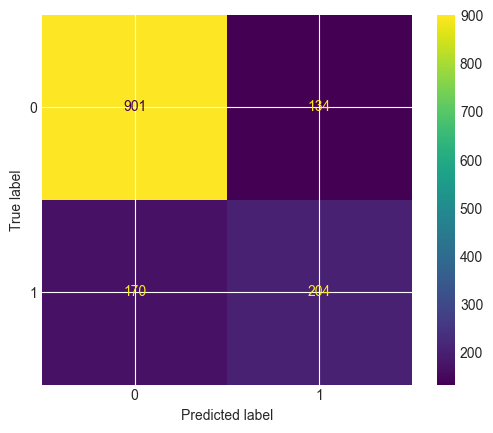

In [67]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_model, X_test_selected, y_test)

### 6.2 Analise as probabilidades

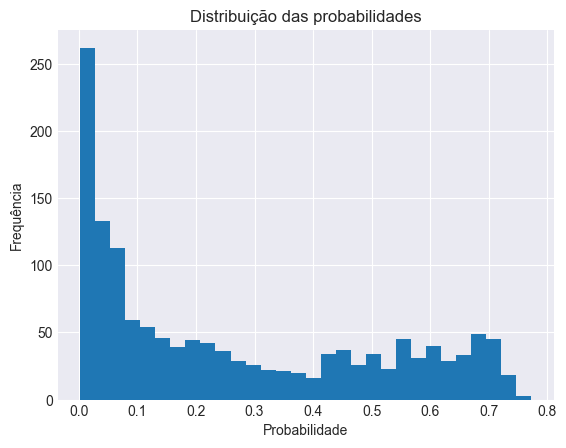

In [68]:
import matplotlib.pyplot as plt

plt.hist(y_proba, bins=30)
plt.title("Distribuição das probabilidades")
plt.xlabel("Probabilidade")
plt.ylabel("Frequência")
plt.show()

### 6.3 Precision × Recall

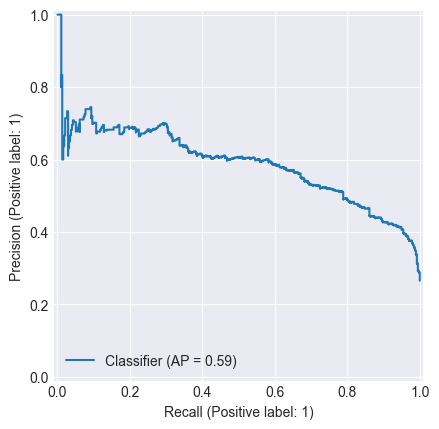

In [54]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, y_proba)

### 6.4 Importância de Features

In [62]:
from sklearn.inspection import permutation_importance

print("== Importância de Features do Melhor Modelo ==")

# Garantias: execute a seção de tuning antes desta célula
assert "best_model" in globals(), "best_model não encontrado. Execute a seção de tuning antes."
assert "final_metrics" in globals(), "final_metrics não encontrado. Execute a seção de tuning antes."
assert "feature_names" in globals(), "feature_names não encontrado. Use os nomes originais do dataset."

# IMPORTANTE: feature_names inclui TODAS as colunas originais
# Precisamos excluir 'target' se existir para fazer match com o mask
all_features = np.array(feature_names)
if 'target' in all_features:
    all_features = all_features[all_features != 'target']

print(f"Features disponíveis após exclusão de target: {len(all_features)}")

# Extrair nomes de features utilizados pelo pipeline (após selector, se houver)
if hasattr(best_model, "named_steps") and "selector" in best_model.named_steps and hasattr(best_model.named_steps["selector"], "get_support"):
    mask = best_model.named_steps["selector"].get_support()
    print(f"Mask size: {len(mask)}, All features size: {len(all_features)}")
    
    # Aplicar máscara SEMPRE (mesmo que tamanhos sejam diferentes)
    # Isso vai selecionar apenas as features onde mask=True
    feat_names_used = all_features[mask]
    print(f"Features após aplicar mask: {len(feat_names_used)}")
else:
    feat_names_used = all_features

print(f"Número de features utilizadas: {len(feat_names_used)}")
print(f"Primeiras 5 features: {feat_names_used[:5]}")

# 1) Importância baseada em árvore (Gini)
model_step = best_model.named_steps["model"] if hasattr(best_model, "named_steps") and "model" in best_model.named_steps else best_model
tree_imp = getattr(model_step, "feature_importances_", None)

figs_to_log = []

if tree_imp is not None:
    # Verificar se há mismatch entre número de features e importâncias
    if len(tree_imp) != len(feat_names_used):
        print(f"⚠️  Aviso: {len(tree_imp)} importâncias para {len(feat_names_used)} features")
        # Usar apenas o que temos
        n_use = min(len(tree_imp), len(feat_names_used))
        feat_names_used = feat_names_used[:n_use]
        tree_imp = tree_imp[:n_use]
    
    imp_df = pd.DataFrame({"feature": feat_names_used, "importance": tree_imp}).sort_values("importance", ascending=False)
    display(imp_df.head(20))

    fig, ax = plt.subplots(figsize=(10, min(0.4*len(imp_df.head(20)), 10)))
    sns.barplot(data=imp_df.head(20), x="importance", y="feature", palette="Blues_r", ax=ax)
    ax.set_title("Importância de Features (Gini) - Top 20")
    ax.set_xlabel("Importância (Gini)")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    figs_to_log.append(("feature_importance_gini_top20.png", fig))
    plt.show()
else:
    print("[Info] Modelo não expõe feature_importances_. Pulando gráfico Gini.")

# 2) Importância por permutação (F1)
try:
    perm = permutation_importance(best_model, X_test, y_test, scoring="f1", n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
    perm_df = pd.DataFrame({
        "feature": feat_names_used,
        "importance": perm.importances_mean,
        "std": perm.importances_std
    }).sort_values("importance", ascending=False)
    display(perm_df.head(20))

    fig2, ax2 = plt.subplots(figsize=(10, min(0.4*len(perm_df.head(20)), 10)))
    sns.barplot(data=perm_df.head(20), x="importance", y="feature", palette="Oranges_r", ax=ax2)
    ax2.set_title("Importância por Permutação (F1) - Top 20")
    ax2.set_xlabel("Queda média na métrica (F1)")
    ax2.set_ylabel("Feature")
    plt.tight_layout()
    figs_to_log.append(("feature_importance_permutation_top20.png", fig2))
    plt.show()
except Exception as e:
    print(f"⚠️  Erro ao calcular importância por permutação: {e}")
    print("   Verifique se X_test e y_test foram preparados corretamente.")



== Importância de Features do Melhor Modelo ==
Features disponíveis após exclusão de target: 29
Mask size: 25, All features size: 29


IndexError: boolean index did not match indexed array along axis 0; size of axis is 29 but size of corresponding boolean axis is 25

## 7. Persistência do modelo para re-uso

In [69]:
import os

# Persistência local com joblib
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

joblib_path = os.path.join(models_dir, f"best_model.joblib")
joblib.dump(best_model, joblib_path)
print(f"Modelo salvo via joblib em: {joblib_path}")

# Log no MLflow: abrir um novo run para registrar artefatos e o modelo salvo
mlflow.set_experiment("aula3_time_budget_tuning")
with mlflow.start_run(run_name="rf_importances_and_persistence"):
    # Parâmetros/metrics chave para rastreabilidade
    if 'best' in globals() and isinstance(best.get('params'), dict):
        for k, v in best["params"].items():
            mlflow.log_param(k, str(v))
    for k, v in final_metrics.items():
        if v is not None and not (isinstance(v, float) and (np.isnan(v) or np.isinf(v))):
            mlflow.log_metric(k.replace(" ", "_").lower(), float(v))

    # Logar figuras
    for fname, fobj in figs_to_log:
        try:
            mlflow.log_figure(fobj, fname)
        except Exception as e:
            print(f"[Aviso] Falha ao logar figura {fname}: {e}")

    # Logar o pipeline completo e o arquivo joblib como artifact
    mlflow.sklearn.log_model(best_model, artifact_path="sklearn_model")
    mlflow.log_artifact(joblib_path, artifact_path="joblib")

print("Concluído: importâncias, persistência (joblib) e log no MLflow.")


2026/05/19 22:31:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 22:31:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Modelo salvo via joblib em: ../models/best_model.joblib
Concluído: importâncias, persistência (joblib) e log no MLflow.
